<a href="https://colab.research.google.com/github/amritha-279/DS_Customer_Churn_Analysis/blob/main/q24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving getflix_synthetic_dataset_v2.csv to getflix_synthetic_dataset_v2.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("getflix_synthetic_dataset_v2.csv")

df.head()

,CustomerID,age,salary_k,tenure_years,number_of_logins,complaints,engagement_score,subscription_type,region,device_type,signup_date,last_active_date,churn
0,CUST_E3C733E6,45.379254,17.420401,0.17,18,3,6.44,Basic,India,Mobile,2020-07-29,2024-05-19,0
1,CUST_9CA1BA76,38.901590,22.964501,10.00,20,1,29.06,Basic,USA,Smart TV,2018-04-12,2024-08-08,0
2,CUST_DAC2CE28,42.141956,17.902013,4.83,30,3,27.63,Basic,India,Web,2021-01-17,2024-07-13,0
3,CUST_270A241D,52.597429,25.766784,6.09,18,0,19.33,Standard,USA,Mobile,2017-08-10,2024-11-03,0
4,CUST_B5384668,34.602866,40.754629,3.56,25,0,20.67,Premium,India,Mobile,2019-08-03,2024-08-23,0


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (10000, 13)

Columns:
Index(['CustomerID', 'age', 'salary_k', 'tenure_years', 'number_of_logins',
       'complaints', 'engagement_score', 'subscription_type', 'region',
       'device_type', 'signup_date', 'last_active_date', 'churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  object 
 1   age                10000 non-null  float64
 2   salary_k           9703 non-null   float64
 3   tenure_years       9705 non-null   float64
 4   number_of_logins   10000 non-null  int64  
 5   complaints         10000 non-null  int64  
 6   engagement_score   10000 non-null  float64
 7   subscription_type  10000 non-null  object 
 8   region             10000 non-null  object 
 9   device_type        10000 non-null  object 
 10  signup_date        1000

In [ ]:
df.isnull().sum()

,0
CustomerID,0
age,0
salary_k,297
tenure_years,295
number_of_logins,0
complaints,0
engagement_score,0
subscription_type,0
region,0
device_type,0


In [ ]:
df["salary_k"] = df["salary_k"].fillna(df["salary_k"].median())

df["tenure_years"] = df["tenure_years"].fillna(
    df["tenure_years"].median()
)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
age,0
salary_k,0
tenure_years,0
number_of_logins,0
complaints,0
engagement_score,0
subscription_type,0
region,0
device_type,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_active_date"] = pd.to_datetime(df["last_active_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         10000 non-null  object        
 1   age                10000 non-null  float64       
 2   salary_k           10000 non-null  float64       
 3   tenure_years       10000 non-null  float64       
 4   number_of_logins   10000 non-null  int64         
 5   complaints         10000 non-null  int64         
 6   engagement_score   10000 non-null  float64       
 7   subscription_type  10000 non-null  object        
 8   region             10000 non-null  object        
 9   device_type        10000 non-null  object        
 10  signup_date        10000 non-null  datetime64[ns]
 11  last_active_date   10000 non-null  datetime64[ns]
 12  churn              10000 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(4)
memory u

In [ ]:
reference_date = df["last_active_date"].max()

df["inactivity_days"] = (
    reference_date - df["last_active_date"]
).dt.days

In [ ]:
df[[
    "CustomerID",
    "last_active_date",
    "inactivity_days",
    "churn"
]].head()

,CustomerID,last_active_date,inactivity_days,churn
0,CUST_E3C733E6,2024-05-19,227,0
1,CUST_9CA1BA76,2024-08-08,146,0
2,CUST_DAC2CE28,2024-07-13,172,0
3,CUST_270A241D,2024-11-03,59,0
4,CUST_B5384668,2024-08-23,131,0


In [ ]:
df.describe()

,age,salary_k,tenure_years,number_of_logins,complaints,engagement_score,signup_date,last_active_date,churn,inactivity_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000
mean,38.107678,28.958831,2.817089,20.523800,2.371600,15.726609,2019-12-09 06:41:36.960000,2024-06-28 23:38:15.360000,0.211400,186.015100
min,17.009219,4.571019,0.000000,4.000000,0.000000,0.970000,2015-01-06 00:00:00,2024-01-03 00:00:00,0.000000,0.000000
25%,31.954629,19.047668,0.887500,17.000000,1.000000,11.440000,2017-06-19 18:00:00,2024-04-03 00:00:00,0.000000,100.000000
50%,38.020307,25.537050,2.060000,20.000000,2.000000,14.725000,2019-11-29 00:00:00,2024-06-29 12:00:00,0.000000,185.500000
75%,44.115492,34.571111,3.960000,23.000000,3.000000,19.060000,2022-05-31 06:00:00,2024-09-23 00:00:00,0.000000,273.000000
max,75.086988,247.856184,10.000000,102.000000,11.000000,38.660000,2024-12-02 00:00:00,2025-01-01 00:00:00,1.000000,364.000000
std,8.895501,16.344460,2.534077,6.423407,1.659515,6.044501,NaN,NaN,0.408322,102.439327


In [ ]:
print(df["subscription_type"].value_counts())

print(df["region"].value_counts())

print(df["device_type"].value_counts())

print(df["churn"].value_counts())

subscription_type
Basic       4863
Standard    4171
Premium      966
Name: count, dtype: int64
region
India      3499
USA        2958
UK         1546
Germany    1000
Canada      997
Name: count, dtype: int64
device_type
Mobile      5047
Web         2997
Smart TV    1956
Name: count, dtype: int64
churn
0    7886
1    2114
Name: count, dtype: int64


In [ ]:
churn_percentage = df["churn"].value_counts(normalize=True) * 100

print(churn_percentage)

churn
0    78.86
1    21.14
Name: proportion, dtype: float64


In [ ]:
segment_analysis = df.groupby("subscription_type").agg(
    Average_Engagement=("engagement_score", "mean"),
    Average_Logins=("number_of_logins", "mean"),
    Average_Inactivity=("inactivity_days", "mean"),
    Churn_Rate=("churn", "mean")
)

segment_analysis["Churn_Rate"] = (
    segment_analysis["Churn_Rate"] * 100
)

segment_analysis

,Average_Engagement,Average_Logins,Average_Inactivity,Churn_Rate
subscription_type,,,,
Basic,16.628937,22.335801,188.488793,36.376722
Premium,13.683468,16.142857,181.829193,3.002070
Standard,15.147768,19.425797,184.100456,7.576121


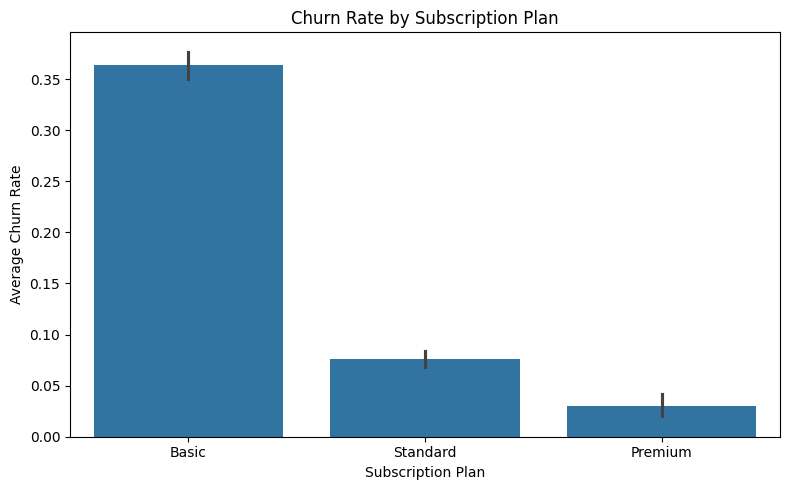

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="subscription_type",
    y="churn"
)

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Average Churn Rate")
plt.tight_layout()
plt.show()

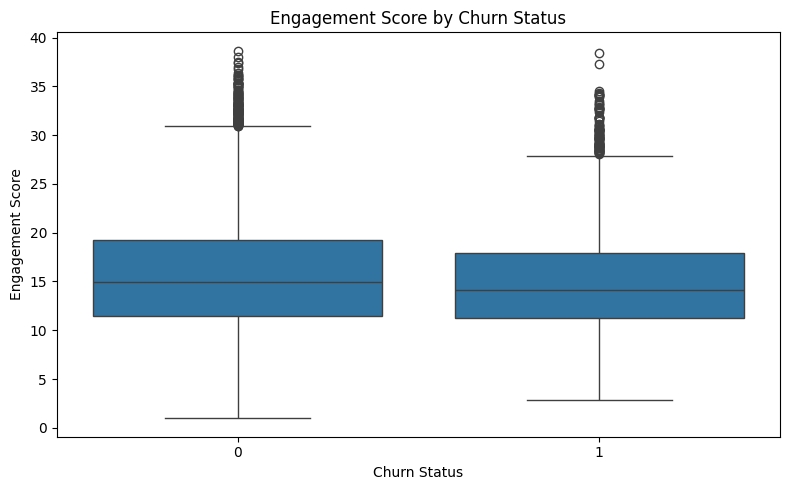

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="engagement_score"
)

plt.title("Engagement Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()

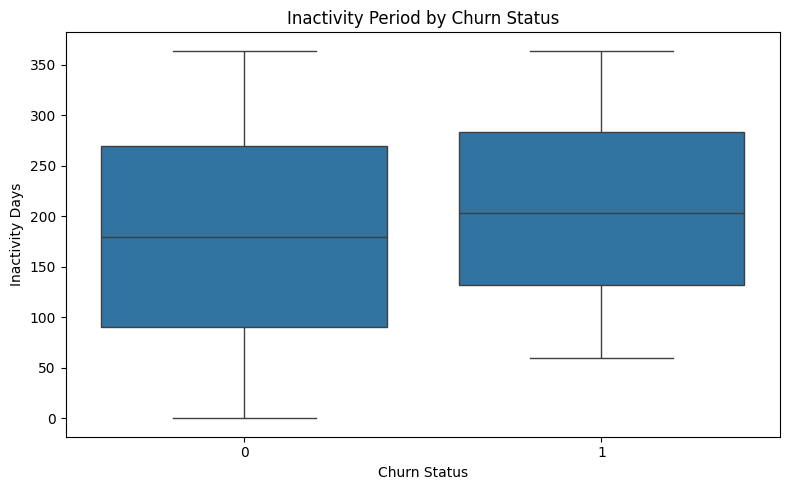

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="inactivity_days"
)

plt.title("Inactivity Period by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Inactivity Days")
plt.tight_layout()
plt.show()

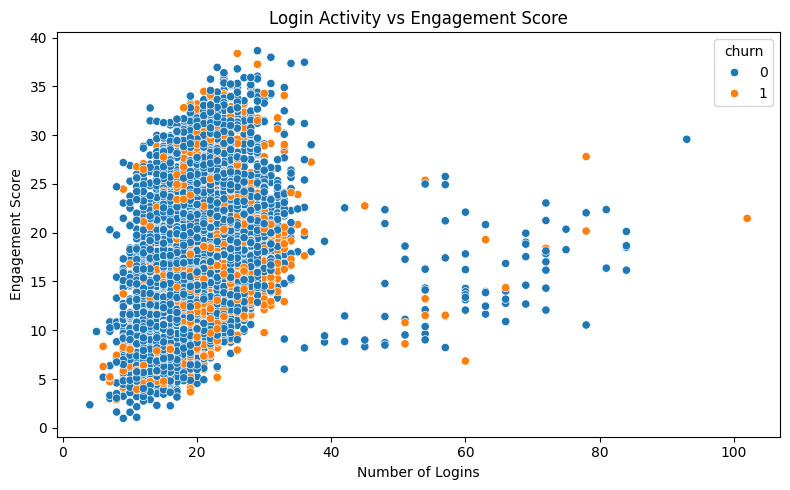

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="number_of_logins",
    y="engagement_score",
    hue="churn"
)

plt.title("Login Activity vs Engagement Score")
plt.xlabel("Number of Logins")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
model_data = df[
    [
        "age",
        "salary_k",
        "tenure_years",
        "number_of_logins",
        "complaints",
        "engagement_score",
        "subscription_type",
        "region",
        "device_type",
        "inactivity_days",
        "churn"
    ]
].copy()

model_data = pd.get_dummies(
    model_data,
    columns=["subscription_type", "region", "device_type"],
    drop_first=True
)

X = model_data.drop("churn", axis=1)
y = model_data["churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9635
Precision: 0.972972972972973
Recall: 0.851063829787234
F1 Score: 0.9079445145018915


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1567   10]
 [  63  360]]


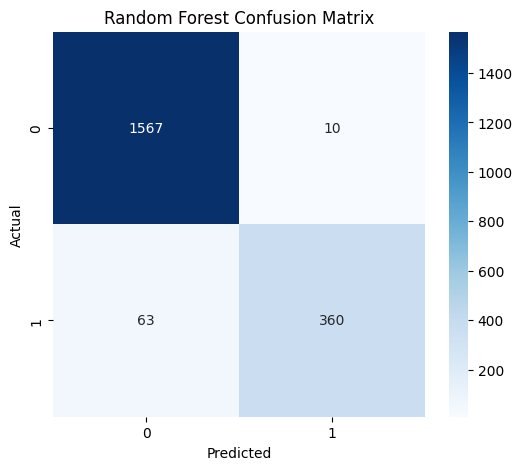

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,complaints,0.429033
1,salary_k,0.165623
2,tenure_years,0.090290
0,age,0.082881
6,inactivity_days,0.061501
5,engagement_score,0.051649
8,subscription_type_Standard,0.048294
3,number_of_logins,0.033941
7,subscription_type_Premium,0.009730
14,device_type_Web,0.005273


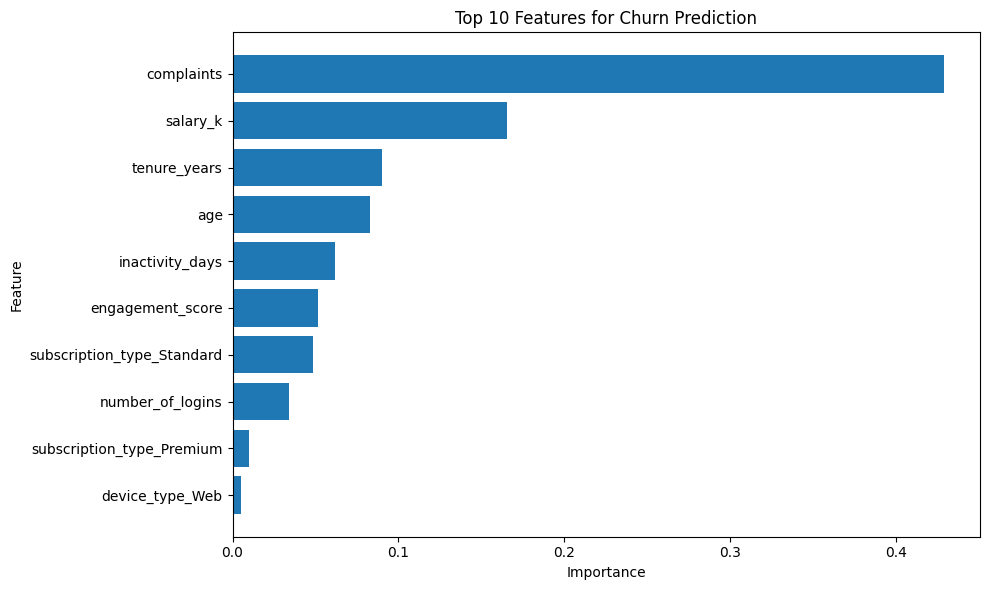

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Practical Action Plan

1. Monitor inactivity
If a user hasn't been active for a long period, the platform can identify them as a possible churn-risk user and send personalized reminders or content recommendations.

2. Focus on Basic-plan users
The Basic plan has the highest observed churn rate, so the company can investigate why these users leave and offer better engagement features or suitable retention offers.

3. Resolve complaints quickly
complaints was the most important feature in our Random Forest model. So the company should prioritize resolving customer complaints.

4. Improve personalization
Recommend content based on the user's previous activity to encourage them to keep watching.

5. Identify high-risk users
Use the Random Forest model to identify users who are likely to churn and target them with retention strategies.
